# Veri Setinin İçe Aktarılması

In [ ]:
from google.colab import drive
import os, shutil

drive.mount("/content/drive")

DRIVE_INPUT = "/content/drive/MyDrive/FiveK/training/INPUT_IMAGES"
LOCAL_INPUT = "/content/FiveK/input"

if os.path.isdir(LOCAL_INPUT) and len(os.listdir(LOCAL_INPUT)) > 0:
    print(f"Content görselleri zaten yerel diskte: {LOCAL_INPUT}")
    print(f"Toplam dosya: {len(os.listdir(LOCAL_INPUT))}")
else:
    if not os.path.isdir(DRIVE_INPUT):
        raise FileNotFoundError(f"Drive'da bulunamadı: {DRIVE_INPUT}")
    print(f"Drive'dan kopyalanıyor: {DRIVE_INPUT} -> {LOCAL_INPUT}")
    print("(Bu işlem 5-15 dk sürebilir, sabırlı olun.)")
    os.makedirs(os.path.dirname(LOCAL_INPUT), exist_ok=True)
    shutil.copytree(DRIVE_INPUT, LOCAL_INPUT)
    print(f"Tamamlandı. Toplam dosya: {len(os.listdir(LOCAL_INPUT))}")

# Örnek dosyaları göster
print("\nÖrnek dosyalar:")
for f in sorted(os.listdir(LOCAL_INPUT))[:5]:
    print(f"  {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive'dan kopyalanıyor: /content/drive/MyDrive/FiveK/training/INPUT_IMAGES -> /content/FiveK/input
(Bu işlem 5-15 dk sürebilir, sabırlı olun.)
Tamamlandı. Toplam dosya: 17675

Örnek dosyalar:
  a0001-jmac_DSC1459_0.JPG
  a0001-jmac_DSC1459_N1.5.JPG
  a0001-jmac_DSC1459_N1.JPG
  a0001-jmac_DSC1459_P1.5.JPG
  a0001-jmac_DSC1459_P1.JPG


# Kütüphane Kurulumu

In [ ]:
# Bu hücre Colab ortamına gerekli paketleri kurar.
# Sadece ilk çalıştırmada gereklidir; daha sonra atlanabilir.
# Kurulum sonrası runtime'ı yeniden başlatmaya gerek yoktur.

!pip install -q "numpy<2"
!pip install -q transformers==4.41.2
!pip install -q timm==1.0.3
!pip install -q lpips==0.1.4
!pip install -q scikit-image==0.22.0
!pip install -q scipy==1.11.4


# Kütüphane İçe Aktarma ve Cihaz Ayarı

In [ ]:
# Tüm kütüphaneleri içe aktarır ve GPU varsa onu seçer.
# CPU üzerinde çalışırsa optimizasyon çok yavaş olur (uyarı verilir).

import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

import scipy.sparse
import scipy.sparse.linalg

import lpips
from skimage.metrics import structural_similarity as ssim

# Cihaz seçimi: GPU varsa kullan, yoksa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")
if device.type == "cpu":
    print("UYARI: GPU bulunamadı. Colab > Runtime > Change runtime type > GPU seçin.")
else:
    print(f"GPU adı: {torch.cuda.get_device_name(0)}")

Kullanılan cihaz: cuda
GPU adı: NVIDIA A100-SXM4-40GB


# Hiperparametreler

In [ ]:
# --- Veri yolları ---
INPUT_FOLDER = "/content/FiveK/input"
EXPERTC_FOLDER = "/content/drive/MyDrive/FiveK/training/GT_IMAGES"
OUTPUT_FOLDER = "/content/outputs"
STYLE_IMAGE_PATH = "/content/style_reference.jpg"

# --- Görüntü ön işleme ---
MIN_SIDE = 256
MAX_ASPECT_RATIO = 3.0
MAX_SIZE = 512
SIZE_MULTIPLE = 32
DATASET_LIMIT = 1000

# --- Normalizasyon (ImageNet) ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# --- Kayıp ağırlıkları ---
ALPHA_CONTENT = 1.0
GAMMA_STYLE = 300
LAMBDA_MATTING = 5000

# --- EfficientNet-B4 ara katman indeksleri ---
CONTENT_LAYER_INDICES = [3, 5]
STYLE_LAYER_INDICES = [1, 3, 5, 7]

# --- Optimizasyon ---
NUM_STEPS = 400
LOG_EVERY = 50
LBFGS_LR = 1.0

# --- Matting Laplacian ---
MATTING_WIN_RAD = 1
MATTING_EPS = 1e-7

# --- SegFormer ---
SEGFORMER_MODEL_NAME = "nvidia/segformer-b2-finetuned-ade-512-512"

# --- Ablasyon ---
LAMBDA_ABLATION_VALUES = [1, 100, 10000, 1000000]

print("Hiperparametreler tanımlandı.")
print(f"Lütfen stil görselinizi şu yola yükleyin: {STYLE_IMAGE_PATH}")

Hiperparametreler tanımlandı.
Lütfen stil görselinizi şu yola yükleyin: /content/style_reference.jpg


# Klasör Doğrulama

In [ ]:
input_exists = os.path.isdir(INPUT_FOLDER)
print(f"input klasörü mevcut mu? {input_exists} ({INPUT_FOLDER})")

if not input_exists:
    raise FileNotFoundError(
        f"input klasörü bulunamadı: {INPUT_FOLDER}. "
        "Hücre 0B'yi çalıştırdığınızdan emin olun."
    )

n_files = len(os.listdir(INPUT_FOLDER))
print(f"Klasördeki dosya sayısı: {n_files}")

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
print(f"Çıktı klasörü hazır: {OUTPUT_FOLDER}")

input klasörü mevcut mu? True (/content/FiveK/input)
Klasördeki dosya sayısı: 17675
Çıktı klasörü hazır: /content/outputs


# HÜCRE 5: Veri Ön İşleme - Filtreleme ve Geçerli Dosya Listesi

In [ ]:
# input klasöründeki tüm görüntüleri tarar (büyük/küçük harf duyarsız).
# Bozuk, çok küçük veya aspect ratio'su yüksek olanları filtreler.
# DATASET_LIMIT (300) görüntüye ulaşınca durur.

# Tüm dosyaları al, uzantıyı sonradan filtrele (büyük/küçük harf bağımsız)
EXTENSIONS = (".jpg", ".jpeg", ".png", ".tif", ".tiff")
all_files = sorted([
    os.path.join(INPUT_FOLDER, f)
    for f in os.listdir(INPUT_FOLDER)
    if f.lower().endswith(EXTENSIONS)
])
print(f"Toplam dosya sayısı: {len(all_files)}")

valid_files = []
rejected_count = 0

for file_path in all_files:
    if len(valid_files) >= DATASET_LIMIT:
        break
    try:
        with Image.open(file_path) as img:
            img.verify()
        # verify sonrası tekrar açmak gerekiyor
        with Image.open(file_path) as img:
            w, h = img.size
            short_side = min(w, h)
            aspect = max(w, h) / min(w, h)
            if short_side < MIN_SIDE:
                rejected_count += 1
                continue
            if aspect > MAX_ASPECT_RATIO:
                rejected_count += 1
                continue
        valid_files.append(file_path)
    except Exception:
        rejected_count += 1
        continue

print(f"Geçerli görüntü sayısı: {len(valid_files)}")
print(f"Reddedilen görüntü sayısı: {rejected_count}")
print(f"İlk 3 örnek dosya: {[os.path.basename(p) for p in valid_files[:3]]}")

Toplam dosya sayısı: 17675
Geçerli görüntü sayısı: 1000
Reddedilen görüntü sayısı: 0
İlk 3 örnek dosya: ['a0001-jmac_DSC1459_0.JPG', 'a0001-jmac_DSC1459_N1.5.JPG', 'a0001-jmac_DSC1459_N1.JPG']


# HÜCRE 6: Görüntü Yükleme, Transform ve Örnek Görsel Gösterimi

Seçilen content görseli: /content/FiveK/input/a0091-jmac_MG_4959_0.JPG
Content tensör boyutu: torch.Size([1, 3, 352, 512])
Stil tensör boyutu: torch.Size([1, 3, 352, 512])


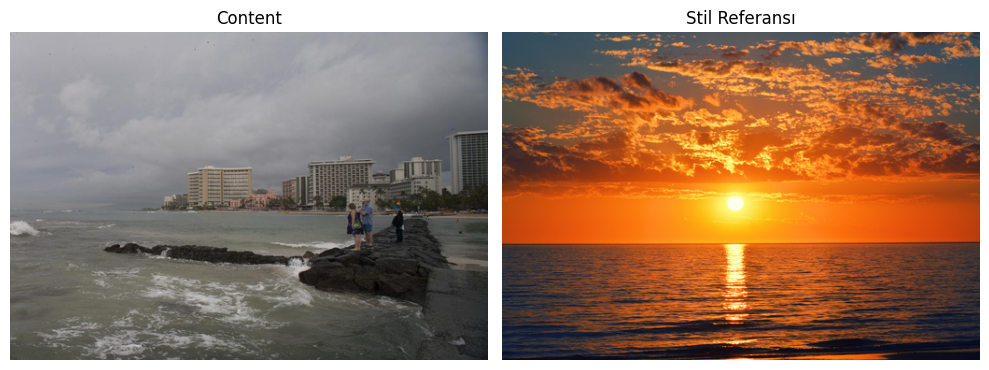

In [ ]:
# Bir görüntüyü açar, uzun kenarı 512px olacak şekilde yeniden boyutlandırır,
# ImageNet ortalama/std ile normalize eder ve tensöre dönüştürür.
# Örnek olarak ilk content görseli ile (varsa) stil görseli yüklenir.

# Kullanılacak content görselini seç (varsayılan: ilk geçerli görsel)
content_path_example = os.path.join(INPUT_FOLDER, "a0091-jmac_MG_4959_0.JPG")
print(f"Seçilen content görseli: {content_path_example}")

# Görüntü yükleme - content
img_content_pil = Image.open(content_path_example).convert("RGB")
w0, h0 = img_content_pil.size
scale = MAX_SIZE / max(w0, h0)
new_w = int(round(w0 * scale / SIZE_MULTIPLE) * SIZE_MULTIPLE)
new_h = int(round(h0 * scale / SIZE_MULTIPLE) * SIZE_MULTIPLE)
new_w = max(new_w, SIZE_MULTIPLE)
new_h = max(new_h, SIZE_MULTIPLE)
img_content_resized = img_content_pil.resize((new_w, new_h), Image.LANCZOS)

content_np = np.array(img_content_resized).astype(np.float32) / 255.0  # H,W,3 [0,1]
content_tensor = torch.from_numpy(content_np).permute(2, 0, 1).unsqueeze(0).to(device)  # 1,3,H,W

mean_t = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
std_t = torch.tensor(IMAGENET_STD, device=device).view(1, 3, 1, 1)
content_norm = (content_tensor - mean_t) / std_t

print(f"Content tensör boyutu: {content_tensor.shape}")

# Stil görselini yükle (varsa)
if os.path.isfile(STYLE_IMAGE_PATH):
    img_style_pil = Image.open(STYLE_IMAGE_PATH).convert("RGB")
    ws, hs = img_style_pil.size
    scale_s = MAX_SIZE / max(ws, hs)
    new_ws = int(round(ws * scale_s / SIZE_MULTIPLE) * SIZE_MULTIPLE)
    new_hs = int(round(hs * scale_s / SIZE_MULTIPLE) * SIZE_MULTIPLE)
    new_ws = max(new_ws, SIZE_MULTIPLE)
    new_hs = max(new_hs, SIZE_MULTIPLE)
    img_style_resized = img_style_pil.resize((new_ws, new_hs), Image.LANCZOS)
    style_np = np.array(img_style_resized).astype(np.float32) / 255.0
    style_tensor = torch.from_numpy(style_np).permute(2, 0, 1).unsqueeze(0).to(device)
    style_norm = (style_tensor - mean_t) / std_t
    print(f"Stil tensör boyutu: {style_tensor.shape}")
else:
    raise FileNotFoundError(
        f"Stil görseli bulunamadı: {STYLE_IMAGE_PATH}. Lütfen yükleyin."
    )

# Örnek gösterim
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(content_np); axes[0].set_title("Content"); axes[0].axis("off")
axes[1].imshow(style_np); axes[1].set_title("Stil Referansı"); axes[1].axis("off")
plt.tight_layout(); plt.show()

HÜCRE 6.5: Stille Anlamsal Benzerlik Bazlı İçerik Seçimi

Stil görselindeki baskın etiket sayısı: 2

En iyi 10 aday (skor / ortak etiket sayısı):
  1. skor=0.796  ortak=2  a0091-jmac_MG_4959_P1.5.JPG
  2. skor=0.795  ortak=2  a0091-jmac_MG_4959_P1.JPG
  3. skor=0.794  ortak=2  a0091-jmac_MG_4959_0.JPG
  4. skor=0.792  ortak=2  a0091-jmac_MG_4959_N1.5.JPG
  5. skor=0.790  ortak=2  a0091-jmac_MG_4959_N1.JPG
  6. skor=0.685  ortak=2  a0223-050816_115418__MG_4849_0.JPG
  7. skor=0.684  ortak=2  a0223-050816_115418__MG_4849_P1.5.JPG
  8. skor=0.684  ortak=2  a0223-050816_115418__MG_4849_P1.JPG
  9. skor=0.684  ortak=2  a0223-050816_115418__MG_4849_N1.JPG
  10. skor=0.683  ortak=2  a0223-050816_115418__MG_4849_N1.5.JPG


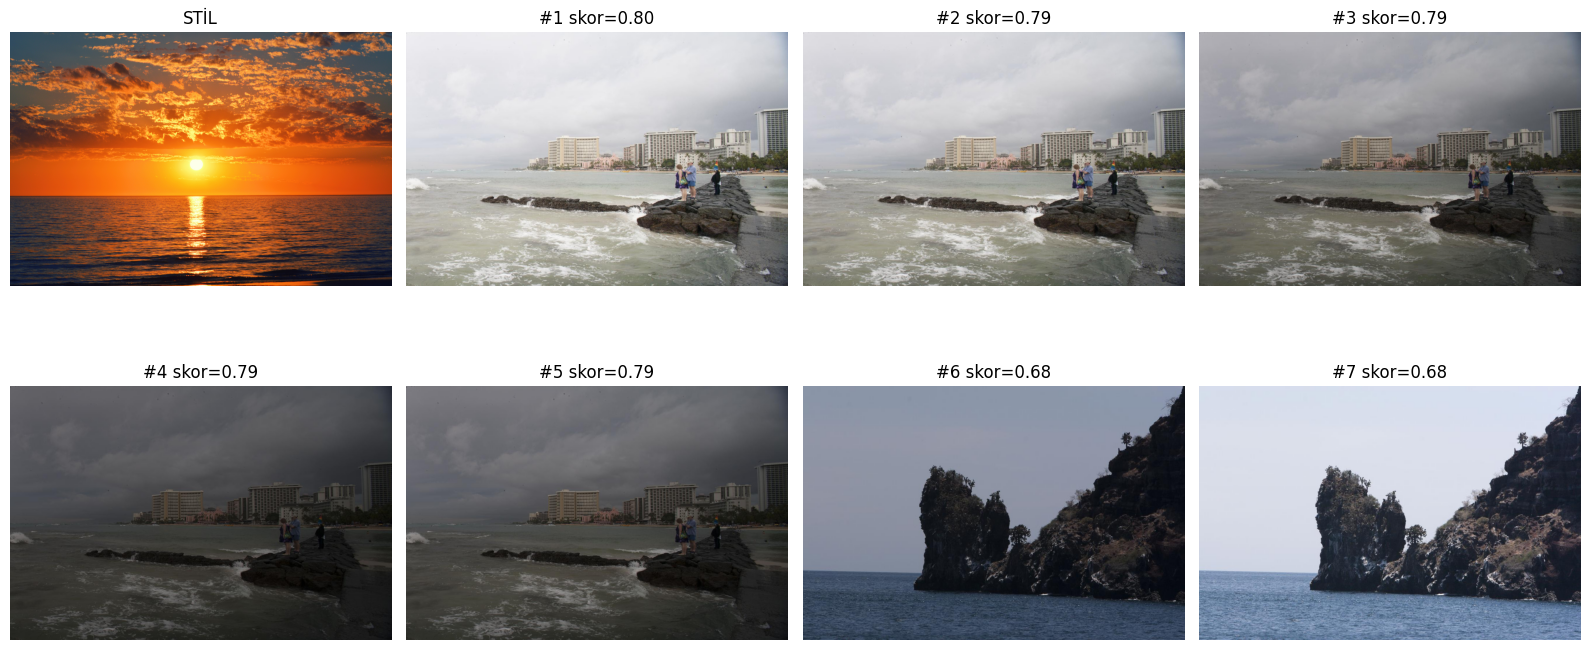

In [ ]:
# Stil görselinin segmentasyon etiketlerini hesaplar.
# Her aday content görseli için aynı etiketlerin örtüşme oranını ölçer.
# En yüksek skorlu ilk 10 görseli listeler — bunlardan birini seçebilirsiniz.

from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

TOP_K_CANDIDATES = 10
RANKING_SAMPLE_SIZE = 1000   # tarama hızı için ilk N'yi inceleriz

# SegFormer'ı erken yükle
seg_proc_tmp = SegformerImageProcessor.from_pretrained(SEGFORMER_MODEL_NAME)
seg_model_tmp = SegformerForSemanticSegmentation.from_pretrained(SEGFORMER_MODEL_NAME).to(device).eval()

# Stil görselinin etiket dağılımı
with torch.no_grad():
    inp = seg_proc_tmp(images=img_style_pil, return_tensors="pt").to(device)
    style_logits = seg_model_tmp(**inp).logits
    style_pred = style_logits.argmax(dim=1)[0].cpu().numpy()
style_labels, style_counts = np.unique(style_pred, return_counts=True)
style_dist = dict(zip(style_labels.tolist(), style_counts.tolist()))
print(f"Stil görselindeki baskın etiket sayısı: {len(style_labels)}")

# Content adaylarını puanla
scores = []
for path in valid_files[:RANKING_SAMPLE_SIZE]:
    try:
        img_pil = Image.open(path).convert("RGB")
        with torch.no_grad():
            inp = seg_proc_tmp(images=img_pil, return_tensors="pt").to(device)
            cont_pred = seg_model_tmp(**inp).logits.argmax(dim=1)[0].cpu().numpy()
        cont_labels, cont_counts = np.unique(cont_pred, return_counts=True)
        cont_dist = dict(zip(cont_labels.tolist(), cont_counts.tolist()))
        # Histogram kesişimi (normalize)
        common = set(style_dist.keys()) & set(cont_dist.keys())
        s_total = sum(style_dist.values())
        c_total = sum(cont_dist.values())
        score = sum(min(style_dist[l]/s_total, cont_dist[l]/c_total) for l in common)
        scores.append((path, score, len(common)))
    except Exception:
        continue

# Sırala ve göster
scores.sort(key=lambda x: x[1], reverse=True)
print(f"\nEn iyi {TOP_K_CANDIDATES} aday (skor / ortak etiket sayısı):")
for i, (p, s, n) in enumerate(scores[:TOP_K_CANDIDATES]):
    print(f"  {i+1}. skor={s:.3f}  ortak={n}  {os.path.basename(p)}")

# Görsel önizleme: ilk 6 aday + stil
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(np.array(img_style_pil)); axes[0, 0].set_title("STİL"); axes[0, 0].axis("off")
for i, (p, s, n) in enumerate(scores[:7]):
    ax = axes[(i+1)//4, (i+1)%4]
    img = Image.open(p).convert("RGB")
    ax.imshow(np.array(img))
    ax.set_title(f"#{i+1} skor={s:.2f}")
    ax.axis("off")
plt.tight_layout(); plt.show()

# HÜCRE 7: EfficientNet-B4 Yükleme ve Ara Katman Çıktıları Test

In [ ]:
# torchvision'dan EfficientNet-B4'ü ImageNet pretrained olarak yükler.
# features[3] ve features[5] çıktılarının boyutlarını yazdırır.
# Modeli eval moduna alır ve gradyan istemez (sabit özellik çıkarıcı).

effnet = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1).to(device)
effnet.eval()
for p in effnet.parameters():
    p.requires_grad = False

# Test girişi: rastgele bir 1x3x256x256 tensör
test_input = torch.randn(1, 3, 256, 256, device=device)

# Ara katman çıktılarını topla
intermediate_outputs = {}
x = test_input
for idx, layer in enumerate(effnet.features):
    x = layer(x)
    if idx in CONTENT_LAYER_INDICES + STYLE_LAYER_INDICES:
        intermediate_outputs[idx] = x

for idx, feat in intermediate_outputs.items():
    role = []
    if idx in CONTENT_LAYER_INDICES: role.append("content")
    if idx in STYLE_LAYER_INDICES:   role.append("stil")
    print(f"features[{idx}] -> {tuple(feat.shape)}  ({', '.join(role)})")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 196MB/s]


features[1] -> (1, 24, 128, 128)  (stil)
features[3] -> (1, 56, 32, 32)  (content, stil)
features[5] -> (1, 160, 16, 16)  (content, stil)
features[7] -> (1, 448, 8, 8)  (stil)


HÜCRE 8: AdaIN Stil Kaybı Hesaplama

In [ ]:
# AdaIN: içerik ve stil özelliklerinin kanal-bazında ortalama/std'lerini eşler.
# Maske destekli versiyonu: her segment etiketi için ayrı ortalama/std hesaplar.
# Maske None ise küresel (global) AdaIN uygulanır.

def adain_style_loss(content_feat, style_feat, content_mask=None, style_mask=None, eps=1e-5):
    # content_feat, style_feat: (1, C, H, W)
    if content_mask is None or style_mask is None:
        c_mean = content_feat.mean(dim=[2, 3], keepdim=True)
        c_std = content_feat.std(dim=[2, 3], keepdim=True) + eps
        s_mean = style_feat.mean(dim=[2, 3], keepdim=True)
        s_std = style_feat.std(dim=[2, 3], keepdim=True) + eps
        loss_mean = F.mse_loss(c_mean, s_mean)
        loss_std = F.mse_loss(c_std, s_std)
        return loss_mean + loss_std
    # Maske destekli: maskeleri özellik boyutuna küçült
    _, _, hc, wc = content_feat.shape
    _, _, hs, ws = style_feat.shape
    c_mask_small = F.interpolate(content_mask, size=(hc, wc), mode="nearest").long().squeeze(0).squeeze(0)
    s_mask_small = F.interpolate(style_mask, size=(hs, ws), mode="nearest").long().squeeze(0).squeeze(0)
    common_labels = set(c_mask_small.unique().tolist()) & set(s_mask_small.unique().tolist())
    total_loss = 0.0
    count = 0
    for label in common_labels:
        c_sel = content_feat[0][:, c_mask_small == label]   # (C, n_c)
        s_sel = style_feat[0][:, s_mask_small == label]      # (C, n_s)
        if c_sel.shape[1] < 2 or s_sel.shape[1] < 2:
            continue
        c_m = c_sel.mean(dim=1, keepdim=True)
        c_s = c_sel.std(dim=1, keepdim=True) + eps
        s_m = s_sel.mean(dim=1, keepdim=True)
        s_s = s_sel.std(dim=1, keepdim=True) + eps
        total_loss = total_loss + F.mse_loss(c_m, s_m) + F.mse_loss(c_s, s_s)
        count += 1
    if count == 0:
        # Hiç ortak etiket yoksa global AdaIN'e düş
        return adain_style_loss(content_feat, style_feat, None, None, eps)
    return total_loss / count

# Hızlı test
with torch.no_grad():
    f1 = torch.randn(1, 32, 64, 64, device=device)
    f2 = torch.randn(1, 32, 48, 48, device=device)
    print(f"Test AdaIN kaybı (global): {adain_style_loss(f1, f2).item():.4f}")

Test AdaIN kaybı (global): 0.0008


HÜCRE 9: İçerik Kaybı Hesaplama

In [ ]:
# İçerik kaybı: çıktı ve content görselinin EfficientNet ara katman
# özellikleri arasındaki MSE.
# Birden fazla katman için kayıpların ortalaması alınır.

def content_loss(output_features, content_features):
    # output_features, content_features: dict {layer_idx: tensor}
    losses = []
    for idx in CONTENT_LAYER_INDICES:
        losses.append(F.mse_loss(output_features[idx], content_features[idx]))
    return torch.stack(losses).mean()

# Hızlı test
with torch.no_grad():
    of = {3: torch.randn(1, 56, 32, 32, device=device),
          5: torch.randn(1, 160, 16, 16, device=device)}
    cf = {3: torch.randn(1, 56, 32, 32, device=device),
          5: torch.randn(1, 160, 16, 16, device=device)}
    print(f"Test içerik kaybı: {content_loss(of, cf).item():.4f}")

Test içerik kaybı: 2.0075


HÜCRE 10: Matting Laplacian Matrisi (scipy.sparse)

In [ ]:
# Levin et al. matting Laplacian'ını 3x3 pencerelerle hesaplar.
# Sonucu (N x N) seyrek matris olarak döndürür (N = H*W).
# Hesaplama imgenin büyüklüğüne göre 10-30 saniye sürebilir.

def compute_matting_laplacian(image_np, win_rad=MATTING_WIN_RAD, eps=MATTING_EPS):
    h, w, c = image_np.shape
    n = h * w
    win_diam = win_rad * 2 + 1
    win_size = win_diam * win_diam

    indices = np.arange(n).reshape(h, w)

    # Tüm pencere merkezleri (kenarlar hariç)
    num_centers = (h - 2 * win_rad) * (w - 2 * win_rad)
    all_inds = np.zeros((num_centers, win_size), dtype=np.int64)
    all_pixels = np.zeros((num_centers, win_size, c), dtype=np.float64)

    k = 0
    for i in range(win_rad, h - win_rad):
        for j in range(win_rad, w - win_rad):
            all_inds[k] = indices[i - win_rad:i + win_rad + 1,
                                  j - win_rad:j + win_rad + 1].flatten()
            all_pixels[k] = image_np[i - win_rad:i + win_rad + 1,
                                     j - win_rad:j + win_rad + 1].reshape(win_size, c)
            k += 1

    # Pencerelerin ortalama ve kovaryansları
    mus = all_pixels.mean(axis=1)                          # (N, 3)
    centered = all_pixels - mus[:, None, :]                # (N, win_size, 3)
    covs = np.einsum("nki,nkj->nij", centered, centered) / win_size
    inv_covs = np.linalg.inv(covs + (eps / win_size) * np.eye(c)[None, :, :])

    # T_n[ki,kj] = (1/win_size)*(1 + X_ki^T inv_cov X_kj)
    Tmats = (1.0 / win_size) * (
        1.0 + np.einsum("nki,nij,nlj->nkl", centered, inv_covs, centered)
    )
    # Pencere katkısı = I - T
    contributions = np.eye(win_size)[None, :, :] - Tmats   # (N, win_size, win_size)

    rows = np.repeat(all_inds[:, :, None], win_size, axis=2).flatten()
    cols = np.repeat(all_inds[:, None, :], win_size, axis=1).flatten()
    vals = contributions.flatten()

    L = scipy.sparse.coo_matrix((vals, (rows, cols)), shape=(n, n))
    return L.tocsr()

# Content görseli için Laplacian hesapla
print("Matting Laplacian hesaplanıyor (biraz sürebilir)...")
L_matting_csr = compute_matting_laplacian(content_np)
print(f"Laplacian boyutu: {L_matting_csr.shape}, nnz: {L_matting_csr.nnz}")

# Torch sparse'a çevir
L_coo = L_matting_csr.tocoo()
L_indices = torch.from_numpy(np.stack([L_coo.row, L_coo.col])).long().to(device)
L_values = torch.from_numpy(L_coo.data).float().to(device)
L_torch = torch.sparse_coo_tensor(L_indices, L_values, L_coo.shape).coalesce()
print("Torch sparse Laplacian hazır.")

Matting Laplacian hesaplanıyor (biraz sürebilir)...
Laplacian boyutu: (180224, 180224), nnz: 4479716
Torch sparse Laplacian hazır.


HÜCRE 11: Matting Laplacian Kaybını Hesaplama

In [ ]:
# Kayıp = Σ_c V_c^T L V_c, V_c çıktının c kanalı (düzleştirilmiş).
# torch.sparse.mm dense'a karşı backward'ı destekler.

def matting_loss(output_image, L_sparse):
    # output_image: (1, 3, H, W) — [0,1] aralığında, normalize EDİLMEMİŞ
    _, c, h, w = output_image.shape
    V = output_image[0].view(c, h * w)        # (3, N)
    LV = torch.sparse.mm(L_sparse, V.t())     # (N, 3)
    loss = (V.t() * LV).sum()
    return loss

# Hızlı test
with torch.no_grad():
    test_img = content_tensor.clone()
    print(f"Test matting kaybı: {matting_loss(test_img, L_torch).item():.4f}")

Test matting kaybı: 0.0350


# HÜCRE 12: SegFormer ile Segmentasyon Maskesi Üretme

Content maskesi: (1, 1, 352, 512), eşsiz etiket: 8
Stil maskesi: (1, 1, 352, 512), eşsiz etiket: 2


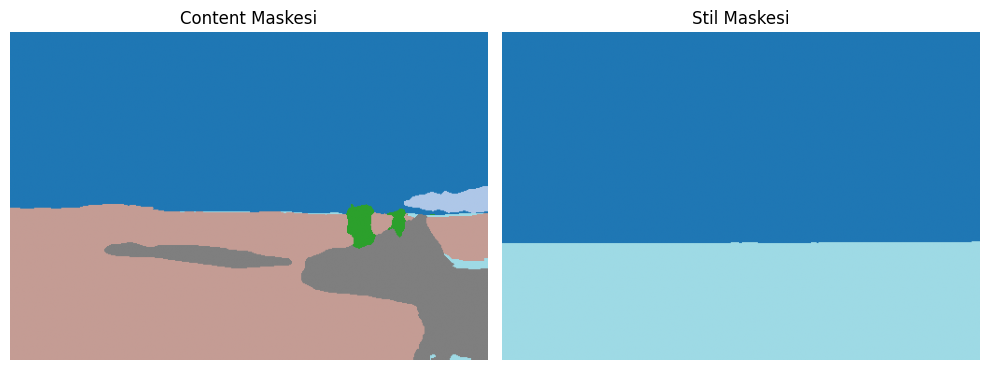

In [ ]:
# SegFormer-B2 (ADE20K) ile content ve stil görsellerinin segment maskelerini çıkarır.
# Çıktı her piksel için bir sınıf etiketi (long tensor) içerir.

seg_processor = SegformerImageProcessor.from_pretrained(SEGFORMER_MODEL_NAME)
seg_model = SegformerForSemanticSegmentation.from_pretrained(SEGFORMER_MODEL_NAME).to(device)
seg_model.eval()
for p in seg_model.parameters():
    p.requires_grad = False

# Content maskesi
with torch.no_grad():
    inputs_c = seg_processor(images=img_content_resized, return_tensors="pt").to(device)
    logits_c = seg_model(**inputs_c).logits
    logits_c_up = F.interpolate(logits_c, size=(content_tensor.shape[2], content_tensor.shape[3]),
                                mode="bilinear", align_corners=False)
    content_mask = logits_c_up.argmax(dim=1, keepdim=True).float()  # (1,1,H,W)

# Stil maskesi
with torch.no_grad():
    inputs_s = seg_processor(images=img_style_resized, return_tensors="pt").to(device)
    logits_s = seg_model(**inputs_s).logits
    logits_s_up = F.interpolate(logits_s, size=(style_tensor.shape[2], style_tensor.shape[3]),
                                mode="bilinear", align_corners=False)
    style_mask = logits_s_up.argmax(dim=1, keepdim=True).float()

print(f"Content maskesi: {tuple(content_mask.shape)}, eşsiz etiket: {len(content_mask.unique())}")
print(f"Stil maskesi: {tuple(style_mask.shape)}, eşsiz etiket: {len(style_mask.unique())}")

# Maskeleri görselleştir
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(content_mask[0, 0].cpu().numpy(), cmap="tab20"); axes[0].set_title("Content Maskesi"); axes[0].axis("off")
axes[1].imshow(style_mask[0, 0].cpu().numpy(), cmap="tab20"); axes[1].set_title("Stil Maskesi"); axes[1].axis("off")
plt.tight_layout(); plt.show()

# HÜCRE 13: Toplam Kayıp Fonksiyonu

In [ ]:
# L_total = alpha*L_content + gamma*L_adain + lambda*L_matting
# Stil özelliklerini önceden tek seferde hesaplar.
# Optimizasyon hücresinde (cell 14) yeniden çağrılır.

def extract_effnet_features(x_normalized, layer_indices):
    feats = {}
    cur = x_normalized
    for idx, layer in enumerate(effnet.features):
        cur = layer(cur)
        if idx in layer_indices:
            feats[idx] = cur
    return feats

def total_loss(output_image_01, content_feats_target, style_feats_target,
               c_mask, s_mask, L_sparse,
               alpha=ALPHA_CONTENT, gamma=GAMMA_STYLE, lam=LAMBDA_MATTING,
               style_loss_fn="adain"):
    # output_image_01: (1,3,H,W), [0,1] aralığında, gradient gerektirir
    # 1) Normalize et ve özellik çıkar
    out_norm = (output_image_01 - mean_t) / std_t
    needed = list(set(CONTENT_LAYER_INDICES + STYLE_LAYER_INDICES))
    out_feats = extract_effnet_features(out_norm, needed)
    # 2) İçerik kaybı
    l_content = content_loss(out_feats, content_feats_target)
    # 3) Stil kaybı
    l_style = 0.0
    for idx in STYLE_LAYER_INDICES:
        if style_loss_fn == "adain":
            l_style = l_style + adain_style_loss(out_feats[idx], style_feats_target[idx],
                                                 c_mask, s_mask)
        else:  # gram matrisi
            of = out_feats[idx]; sf = style_feats_target[idx]
            b, ch, hh, ww = of.shape
            G_o = (of.view(ch, -1) @ of.view(ch, -1).t()) / (ch * hh * ww)
            b2, ch2, hh2, ww2 = sf.shape
            G_s = (sf.view(ch2, -1) @ sf.view(ch2, -1).t()) / (ch2 * hh2 * ww2)
            l_style = l_style + F.mse_loss(G_o, G_s)
    l_style = l_style / len(STYLE_LAYER_INDICES)
    # 4) Matting kaybı
    l_matting = matting_loss(output_image_01, L_sparse)
    # 5) Toplam
    total = alpha * l_content + gamma * l_style + lam * l_matting
    return total, l_content, l_style, l_matting

print("Toplam kayıp fonksiyonu tanımlandı.")

Toplam kayıp fonksiyonu tanımlandı.


# HÜCRE 14: Stil Transferi Optimizasyon Döngüsü (LBFGS, 300 adım)

In [ ]:
# Çıktıyı content görselinin kopyası olarak başlatır ve LBFGS ile günceller.
# Ana çalışma: AdaIN stil kaybı + EfficientNet-B4 backbone.
# Sparse matrix gradyanları için contiguous düzeltmesi içerir.

# Stil ve içerik özelliklerini önceden hesapla
needed_layers = list(set(CONTENT_LAYER_INDICES + STYLE_LAYER_INDICES))
with torch.no_grad():
    content_feats_target = extract_effnet_features(content_norm, needed_layers)
    style_feats_target = extract_effnet_features(style_norm, needed_layers)

# Çıktıyı content'in kopyası olarak başlat (contiguous garantili)
output_image = content_tensor.clone().contiguous().detach().requires_grad_(True)

optimizer = torch.optim.LBFGS([output_image], lr=LBFGS_LR, max_iter=20)

step_counter = [0]
log_history = []

def closure_main():
    optimizer.zero_grad()
    out_clamped = output_image.clamp(0.0, 1.0)
    total, l_c, l_s, l_m = total_loss(
        out_clamped, content_feats_target, style_feats_target,
        content_mask, style_mask, L_torch,
        alpha=ALPHA_CONTENT, gamma=GAMMA_STYLE, lam=LAMBDA_MATTING,
        style_loss_fn="adain",
    )
    total.backward()
    # LBFGS için gradyanı contiguous yap (sparse matmul sonrası gerekli)
    if output_image.grad is not None and not output_image.grad.is_contiguous():
        output_image.grad = output_image.grad.contiguous()
    step_counter[0] += 1
    if step_counter[0] % LOG_EVERY == 0 or step_counter[0] == 1:
        print(f"Adım {step_counter[0]:4d} | toplam={total.item():.4f}  "
              f"içerik={l_c.item():.4f}  stil={l_s.item():.6f}  matting={l_m.item():.4e}")
        log_history.append((step_counter[0], total.item(), l_c.item(), l_s.item(), l_m.item()))
    return total

print("Optimizasyon başlıyor...")
while step_counter[0] < NUM_STEPS:
    optimizer.step(closure_main)

with torch.no_grad():
    output_image.clamp_(0.0, 1.0)
print("Optimizasyon tamamlandı.")
output_main = output_image.detach().clone()

Optimizasyon başlıyor...
Adım    1 | toplam=14518.6523  içerik=0.0000  stil=47.811699  matting=3.5029e-02
Adım   50 | toplam=11399.3271  içerik=41.6721  stil=33.292892  matting=2.7396e-01
Adım  100 | toplam=10024.7324  içerik=60.5428  stil=27.624870  matting=3.3535e-01
Adım  150 | toplam=9038.5254  içerik=69.5434  stil=23.971451  matting=3.5551e-01
Adım  200 | toplam=8338.6875  içerik=72.4825  stil=22.311502  matting=3.1455e-01
Adım  250 | toplam=7849.6001  içerik=76.9891  stil=20.429926  matting=3.2873e-01
Adım  300 | toplam=7414.3237  içerik=78.6045  stil=18.998123  matting=3.2726e-01
Adım  350 | toplam=7069.7603  içerik=80.4153  stil=17.798750  matting=3.2994e-01
Adım  400 | toplam=6758.5820  içerik=82.2675  stil=16.874748  matting=3.2278e-01
Optimizasyon tamamlandı.


HÜCRE 15: Sonucu Görselleştir (Content / Stil / Çıktı)

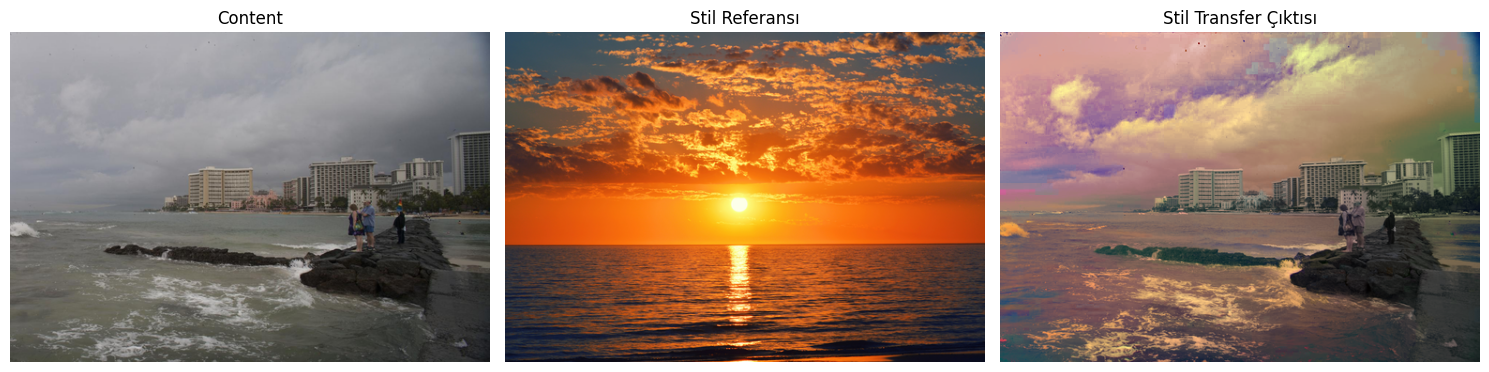

In [ ]:
# Üç görseli yan yana matplotlib ile gösterir.
# Çıktı [0,1] aralığında olduğundan doğrudan imshow'a verilebilir.

output_np = output_main[0].permute(1, 2, 0).cpu().numpy()
output_np = np.clip(output_np, 0.0, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(content_np); axes[0].set_title("Content"); axes[0].axis("off")
axes[1].imshow(style_np); axes[1].set_title("Stil Referansı"); axes[1].axis("off")
axes[2].imshow(output_np); axes[2].set_title("Stil Transfer Çıktısı"); axes[2].axis("off")
plt.tight_layout(); plt.show()

HÜCRE 16: Metrikleri Hesapla (SSIM ve LPIPS)

In [ ]:
# SSIM: skimage ile content'a kıyasla çıktının yapı benzerliği.
# LPIPS: AlexNet tabanlı algısal mesafe (düşük = benzer).
# Sonu: çıktıyı PNG olarak outputs klasörüne kaydeder (üzerine yazar).

# SSIM için boyutları eşle
output_for_metric = output_np.astype(np.float32)
content_for_metric = content_np.astype(np.float32)

ssim_value = ssim(content_for_metric, output_for_metric,
                  channel_axis=2, data_range=1.0)
print(f"SSIM (content vs çıktı): {ssim_value:.4f}")

# LPIPS modeli
lpips_model = lpips.LPIPS(net="alex").to(device).eval()

# LPIPS [-1,1] aralığı bekler
def to_lpips_range(t01):
    return (t01 * 2.0 - 1.0)

with torch.no_grad():
    lpips_value = lpips_model(to_lpips_range(content_tensor),
                              to_lpips_range(output_main)).item()
print(f"LPIPS (content vs çıktı): {lpips_value:.4f}")

# --- Çıktıyı kaydet ---
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
save_arr = (np.clip(output_np, 0, 1) * 255).astype(np.uint8)
config_tag = f"g{int(GAMMA_STYLE)}_l{int(LAMBDA_MATTING)}_s{NUM_STEPS}"
save_path = os.path.join(OUTPUT_FOLDER, "output_base.png")
Image.fromarray(save_arr).save(save_path)
print(f"Çıktı kaydedildi: {save_path}")

SSIM (content vs çıktı): 0.8673
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS (content vs çıktı): 0.3647
Çıktı kaydedildi: /content/outputs/output_base.png


HÜCRE 17: Lambda Ablasyon Deneyi


--- lambda = 1 ---
  adım    1 | toplam=14343.5449
  adım   50 | toplam=2125.4880
  adım  100 | toplam=1138.5917
  adım  150 | toplam=808.5216
  adım  200 | toplam=673.4272
  adım  250 | toplam=601.6121
  adım  300 | toplam=553.0840
  adım  350 | toplam=522.7183
  adım  400 | toplam=497.9637

--- lambda = 100 ---
  adım    1 | toplam=14347.0127
  adım   50 | toplam=5129.8799
  adım  100 | toplam=3689.9778
  adım  150 | toplam=3196.1919
  adım  200 | toplam=2843.8799
  adım  250 | toplam=2570.0088
  adım  300 | toplam=2375.0361
  adım  350 | toplam=2221.5308
  adım  400 | toplam=2100.6304

--- lambda = 10000 ---
  adım    1 | toplam=14693.7949
  adım   50 | toplam=12323.4688
  adım  100 | toplam=11184.2705
  adım  150 | toplam=10327.1113
  adım  200 | toplam=9655.6465
  adım  250 | toplam=9128.9473
  adım  300 | toplam=8789.8301
  adım  350 | toplam=8553.7480
  adım  400 | toplam=8235.4111

--- lambda = 1000000 ---
  adım    1 | toplam=49372.0312
  adım   50 | toplam=38251.7812
  adım 

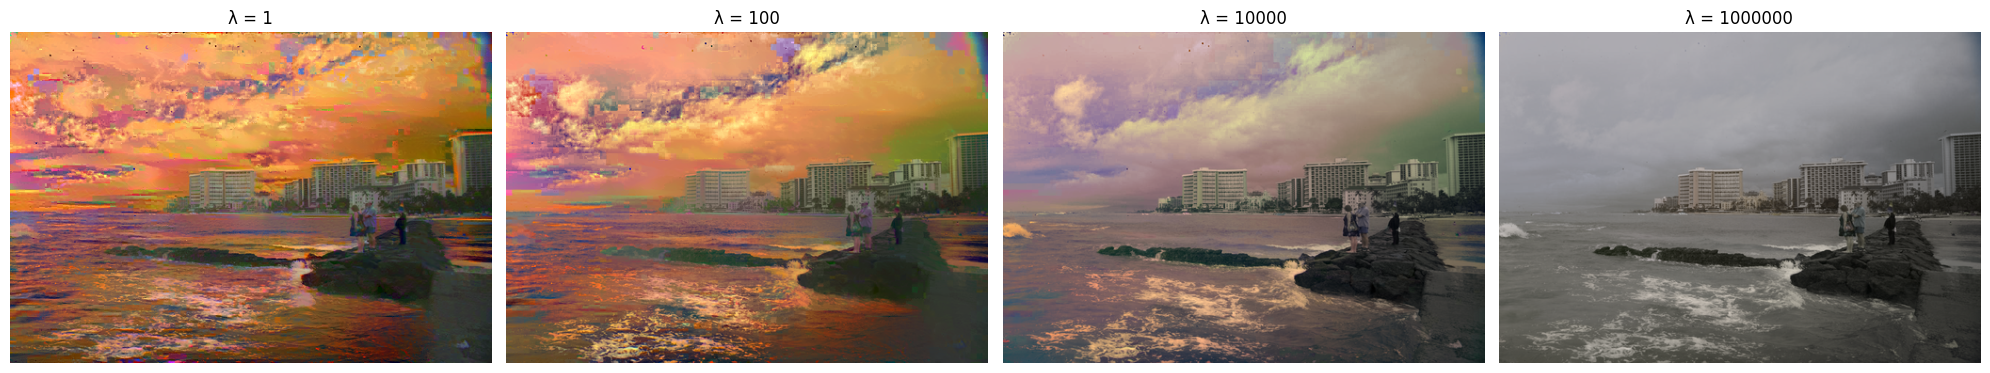

In [ ]:
# LAMBDA_ABLATION_VALUES = [1, 100, 10000, 1000000] için ayrı ayrı çalıştırır.
# Sonuçları 1x4 grid olarak gösterir (Luan et al. Figure 3 tarzı).
# LBFGS contiguous gradyan düzeltmesi içerir.

ablation_outputs = []

for lam_val in LAMBDA_ABLATION_VALUES:
    print(f"\n--- lambda = {lam_val} ---")
    out_img = content_tensor.clone().contiguous().detach().requires_grad_(True)
    opt = torch.optim.LBFGS([out_img], lr=LBFGS_LR, max_iter=20)
    counter = [0]

    def closure_ablation():
        opt.zero_grad()
        out_c = out_img.clamp(0.0, 1.0)
        total, l_c, l_s, l_m = total_loss(
            out_c, content_feats_target, style_feats_target,
            content_mask, style_mask, L_torch,
            alpha=ALPHA_CONTENT, gamma=GAMMA_STYLE, lam=float(lam_val),
            style_loss_fn="adain",
        )
        total.backward()
        # LBFGS için gradyanı contiguous yap
        if out_img.grad is not None and not out_img.grad.is_contiguous():
            out_img.grad = out_img.grad.contiguous()
        counter[0] += 1
        if counter[0] % LOG_EVERY == 0 or counter[0] == 1:
            print(f"  adım {counter[0]:4d} | toplam={total.item():.4f}")
        return total

    while counter[0] < NUM_STEPS:
        opt.step(closure_ablation)
    with torch.no_grad():
        out_img.clamp_(0.0, 1.0)
    ablation_outputs.append((lam_val, out_img.detach().clone()))

# 1x4 görselleştirme
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (lam_val, out_t) in enumerate(ablation_outputs):
    img_np = out_t[0].permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)
    axes[i].imshow(img_np)
    axes[i].set_title(f"λ = {lam_val}")
    axes[i].axis("off")
plt.tight_layout(); plt.show()

# HÜCRE 18: Backbone Karşılaştırması (EfficientNet-B4 vs VGG-19)


[Koşul 1] VGG-19 (gamma=300 - EfficientNet ile eşit)
  VGG-eşit adım    1 | toplam=944.0948
  VGG-eşit adım   50 | toplam=878.5627
  VGG-eşit adım  100 | toplam=856.2205
  VGG-eşit adım  150 | toplam=842.6976
  VGG-eşit adım  200 | toplam=831.1710
  VGG-eşit adım  250 | toplam=822.3793
  VGG-eşit adım  300 | toplam=813.7775
  VGG-eşit adım  350 | toplam=807.5419
  VGG-eşit adım  400 | toplam=800.7323

[Koşul 2] VGG-19 (gamma=3000 - VGG'ye uygun ölçek)
  VGG-ayar adım    1 | toplam=7864.6646
  VGG-ayar adım   50 | toplam=6696.1377
  VGG-ayar adım  100 | toplam=6170.1416
  VGG-ayar adım  150 | toplam=5881.3833
  VGG-ayar adım  200 | toplam=5662.9316
  VGG-ayar adım  250 | toplam=5478.4321
  VGG-ayar adım  300 | toplam=5333.2510
  VGG-ayar adım  350 | toplam=5210.1274
  VGG-ayar adım  400 | toplam=5125.8384

Tablo 1: Eşit Hiperparametre Koşulu (gamma=300)
Backbone                 SSIM    LPIPS
------------------------------------------------------------
EfficientNet-B4        0.8673   0.

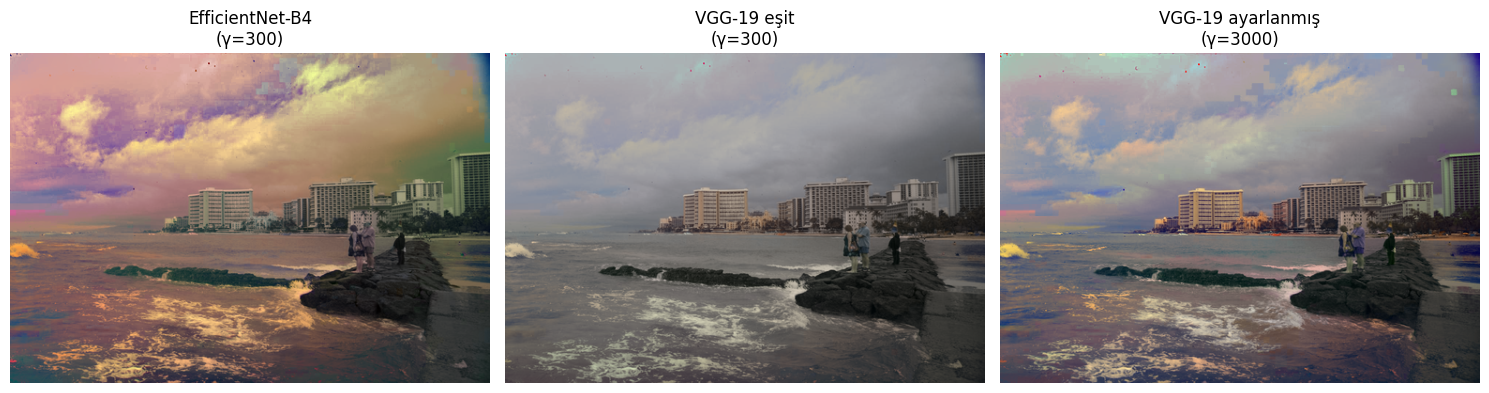

Karşılaştırma kaydedildi: backbone_comparison.png


In [ ]:
# İki koşul: (1) Eşit hiperparametre, (2) VGG için ayarlanmış gamma.
# Mimari farkı + adil karşılaştırma birlikte sunulur.
# LBFGS contiguous gradyan + detach düzeltmeleri içerir.

# --- VGG-19 yükle ve katman indekslerini belirle ---
vgg19 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features.to(device).eval()
for p in vgg19.parameters():
    p.requires_grad = False

VGG_CONTENT_LAYERS = [22]                    # conv4_2
VGG_STYLE_LAYERS = [1, 6, 11, 20, 29]        # relu1_1, 2_1, 3_1, 4_1, 5_1

# VGG için ayarlanmış stil ağırlığı (adil karşılaştırma için)
GAMMA_STYLE_VGG = 3000   # EfficientNet 300 ile orantılı stil etkisi için ~10x

def extract_vgg_features(x_normalized, layer_indices):
    feats = {}
    cur = x_normalized
    for idx, layer in enumerate(vgg19):
        cur = layer(cur)
        if idx in layer_indices:
            feats[idx] = cur
        if idx > max(layer_indices):
            break
    return feats

# VGG hedef özelliklerini önceden hesapla
needed_vgg = list(set(VGG_CONTENT_LAYERS + VGG_STYLE_LAYERS))
with torch.no_grad():
    c_feats_vgg = extract_vgg_features(content_norm, needed_vgg)
    s_feats_vgg = extract_vgg_features(style_norm, needed_vgg)


# ----------------------------------------------------------------
# Genel VGG optimizasyonu fonksiyonu (her iki koşulda da çağrılır)
# ----------------------------------------------------------------
def run_vgg_optimization(gamma_value, label):
    out_vgg = content_tensor.clone().contiguous().detach().requires_grad_(True)
    opt_vgg = torch.optim.LBFGS([out_vgg], lr=LBFGS_LR, max_iter=20)
    counter = [0]

    def closure_vgg():
        opt_vgg.zero_grad()
        out_c = out_vgg.clamp(0.0, 1.0)
        out_n = (out_c - mean_t) / std_t
        out_feats = extract_vgg_features(out_n, needed_vgg)
        l_c = torch.stack([F.mse_loss(out_feats[i], c_feats_vgg[i]) for i in VGG_CONTENT_LAYERS]).mean()
        l_s = 0.0
        for i in VGG_STYLE_LAYERS:
            l_s = l_s + adain_style_loss(out_feats[i], s_feats_vgg[i], content_mask, style_mask)
        l_s = l_s / len(VGG_STYLE_LAYERS)
        l_m = matting_loss(out_c, L_torch)
        total = ALPHA_CONTENT * l_c + gamma_value * l_s + LAMBDA_MATTING * l_m
        total.backward()
        if out_vgg.grad is not None and not out_vgg.grad.is_contiguous():
            out_vgg.grad = out_vgg.grad.contiguous()
        counter[0] += 1
        if counter[0] % LOG_EVERY == 0 or counter[0] == 1:
            print(f"  {label} adım {counter[0]:4d} | toplam={total.item():.4f}")
        return total

    while counter[0] < NUM_STEPS:
        opt_vgg.step(closure_vgg)
    with torch.no_grad():
        out_vgg.clamp_(0.0, 1.0)
    return out_vgg.detach().clone()


# --- Koşul 1: Eşit gamma (EfficientNet ile aynı) ---
print(f"\n[Koşul 1] VGG-19 (gamma={GAMMA_STYLE} - EfficientNet ile eşit)")
out_vgg_equal = run_vgg_optimization(GAMMA_STYLE, "VGG-eşit")

# --- Koşul 2: Ayarlanmış gamma (adil karşılaştırma) ---
print(f"\n[Koşul 2] VGG-19 (gamma={GAMMA_STYLE_VGG} - VGG'ye uygun ölçek)")
out_vgg_tuned = run_vgg_optimization(GAMMA_STYLE_VGG, "VGG-ayar")


# --- Metrikler ---
out_eff_np = np.clip(output_main.detach()[0].permute(1, 2, 0).cpu().numpy(), 0, 1)
out_vgg_equal_np = np.clip(out_vgg_equal[0].permute(1, 2, 0).cpu().numpy(), 0, 1)
out_vgg_tuned_np = np.clip(out_vgg_tuned[0].permute(1, 2, 0).cpu().numpy(), 0, 1)

content_for_metric = content_np.astype(np.float32)
ssim_eff = ssim(content_for_metric, out_eff_np.astype(np.float32),
                channel_axis=2, data_range=1.0)
ssim_vgg_equal = ssim(content_for_metric, out_vgg_equal_np.astype(np.float32),
                      channel_axis=2, data_range=1.0)
ssim_vgg_tuned = ssim(content_for_metric, out_vgg_tuned_np.astype(np.float32),
                      channel_axis=2, data_range=1.0)
with torch.no_grad():
    lpips_eff = lpips_model(to_lpips_range(content_tensor),
                            to_lpips_range(output_main.detach())).item()
    lpips_vgg_equal = lpips_model(to_lpips_range(content_tensor),
                                  to_lpips_range(out_vgg_equal)).item()
    lpips_vgg_tuned = lpips_model(to_lpips_range(content_tensor),
                                  to_lpips_range(out_vgg_tuned)).item()


# --- İki tablo ---
print("\n" + "=" * 60)
print("Tablo 1: Eşit Hiperparametre Koşulu (gamma={})".format(GAMMA_STYLE))
print("=" * 60)
print(f"{'Backbone':<20} {'SSIM':>8} {'LPIPS':>8}")
print("-" * 60)
print(f"{'EfficientNet-B4':<20} {ssim_eff:>8.4f} {lpips_eff:>8.4f}")
print(f"{'VGG-19':<20} {ssim_vgg_equal:>8.4f} {lpips_vgg_equal:>8.4f}")

print("\n" + "=" * 60)
print(f"Tablo 2: Adil Karşılaştırma (her backbone'a özgü gamma)")
print("=" * 60)
print(f"{'Backbone':<20} {'gamma':>8} {'SSIM':>8} {'LPIPS':>8}")
print("-" * 60)
print(f"{'EfficientNet-B4':<20} {GAMMA_STYLE:>8} {ssim_eff:>8.4f} {lpips_eff:>8.4f}")
print(f"{'VGG-19 (ayar)':<20} {GAMMA_STYLE_VGG:>8} {ssim_vgg_tuned:>8.4f} {lpips_vgg_tuned:>8.4f}")


# --- 1x3 görselleştirme ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(out_eff_np)
axes[0].set_title(f"EfficientNet-B4\n(γ={GAMMA_STYLE})")
axes[0].axis("off")
axes[1].imshow(out_vgg_equal_np)
axes[1].set_title(f"VGG-19 eşit\n(γ={GAMMA_STYLE})")
axes[1].axis("off")
axes[2].imshow(out_vgg_tuned_np)
axes[2].set_title(f"VGG-19 ayarlanmış\n(γ={GAMMA_STYLE_VGG})")
axes[2].axis("off")
plt.tight_layout(); plt.show()

# Üçlü karşılaştırmayı PNG olarak kaydet
combined = np.concatenate([out_eff_np, out_vgg_equal_np, out_vgg_tuned_np], axis=1)
combined_uint8 = (combined * 255).astype(np.uint8)
Image.fromarray(combined_uint8).save(os.path.join(OUTPUT_FOLDER, "backbone_comparison.png"))
print("Karşılaştırma kaydedildi: backbone_comparison.png")

# HÜCRE 19: Stil Kaybı Karşılaştırması (AdaIN vs Gram Matrisi)

Gram matrisi tabanlı optimizasyon...
Gram adım    1 | toplam=828.7961
Gram adım   50 | toplam=775.5026
Gram adım  100 | toplam=759.4215
Gram adım  150 | toplam=746.3135
Gram adım  200 | toplam=731.8313
Gram adım  250 | toplam=715.3848
Gram adım  300 | toplam=699.2346
Gram adım  350 | toplam=682.6157
Gram adım  400 | toplam=661.9229

--- Stil Kaybı Karşılaştırması ---
Stil Kaybı               SSIM    LPIPS
----------------------------------------
AdaIN                  0.8673   0.3647
Gram Matrisi           0.9807   0.1382


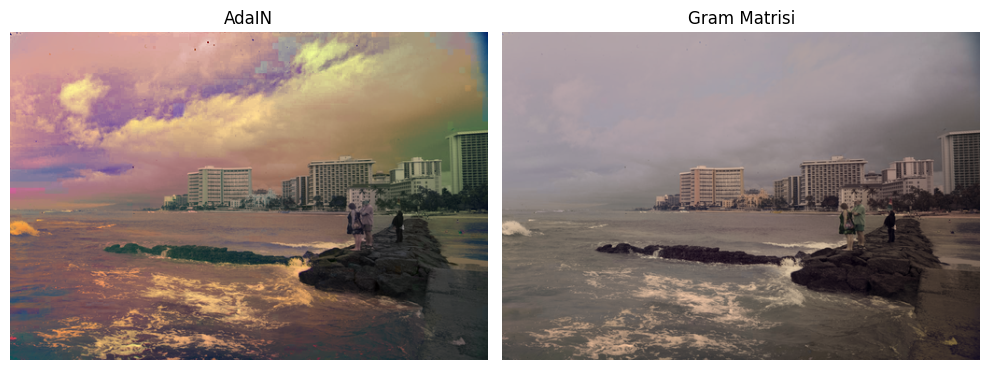

In [ ]:
# Aynı backbone (EfficientNet-B4) ile iki farklı stil kaybı çalıştırır.
# SSIM ve LPIPS değerlerini tablo olarak yazdırır.
# LBFGS contiguous gradyan düzeltmesi ve detach düzeltmesi içerir.

# AdaIN sonucu zaten elimizde: output_main
# Gram için yeni optimizasyon
out_gram = content_tensor.clone().contiguous().detach().requires_grad_(True)
opt_gram = torch.optim.LBFGS([out_gram], lr=LBFGS_LR, max_iter=20)
counter_g = [0]

def closure_gram():
    opt_gram.zero_grad()
    out_c = out_gram.clamp(0.0, 1.0)
    total, l_c, l_s, l_m = total_loss(
        out_c, content_feats_target, style_feats_target,
        content_mask, style_mask, L_torch,
        alpha=ALPHA_CONTENT, gamma=GAMMA_STYLE, lam=LAMBDA_MATTING,
        style_loss_fn="gram",
    )
    total.backward()
    # LBFGS için gradyanı contiguous yap
    if out_gram.grad is not None and not out_gram.grad.is_contiguous():
        out_gram.grad = out_gram.grad.contiguous()
    counter_g[0] += 1
    if counter_g[0] % LOG_EVERY == 0 or counter_g[0] == 1:
        print(f"Gram adım {counter_g[0]:4d} | toplam={total.item():.4f}")
    return total

print("Gram matrisi tabanlı optimizasyon...")
while counter_g[0] < NUM_STEPS:
    opt_gram.step(closure_gram)
with torch.no_grad():
    out_gram.clamp_(0.0, 1.0)

# Detach ile gradient grafiğinden ayır, sonra numpy'a çevir
out_eff_np = np.clip(output_main.detach()[0].permute(1, 2, 0).cpu().numpy(), 0, 1)
out_gram_np = np.clip(out_gram.detach()[0].permute(1, 2, 0).cpu().numpy(), 0, 1)

ssim_adain = ssim(content_np.astype(np.float32), out_eff_np.astype(np.float32),
                  channel_axis=2, data_range=1.0)
ssim_gram = ssim(content_np.astype(np.float32), out_gram_np.astype(np.float32),
                 channel_axis=2, data_range=1.0)
with torch.no_grad():
    lpips_adain = lpips_model(to_lpips_range(content_tensor),
                              to_lpips_range(output_main.detach())).item()
    lpips_gram = lpips_model(to_lpips_range(content_tensor),
                             to_lpips_range(out_gram.detach())).item()

print("\n--- Stil Kaybı Karşılaştırması ---")
print(f"{'Stil Kaybı':<20} {'SSIM':>8} {'LPIPS':>8}")
print("-" * 40)
print(f"{'AdaIN':<20} {ssim_adain:>8.4f} {lpips_adain:>8.4f}")
print(f"{'Gram Matrisi':<20} {ssim_gram:>8.4f} {lpips_gram:>8.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(out_eff_np); axes[0].set_title("AdaIN"); axes[0].axis("off")
axes[1].imshow(out_gram_np); axes[1].set_title("Gram Matrisi"); axes[1].axis("off")
plt.tight_layout(); plt.show()

# HÜCRE 20: Tüm Sonuçları PNG Olarak Kaydet

In [ ]:
# Ana çıktı, ablasyon görselleri, backbone ve stil-kaybı karşılaştırma
# çıktılarını OUTPUT_FOLDER altına PNG olarak yazar.

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def save_tensor_as_png(t01, path):
    arr = (np.clip(t01[0].permute(1, 2, 0).cpu().numpy(), 0, 1) * 255).astype(np.uint8)
    Image.fromarray(arr).save(path)

# Ana çıktı
save_tensor_as_png(output_main, os.path.join(OUTPUT_FOLDER, "output_main.png"))

# Lambda ablasyon
for lam_val, t in ablation_outputs:
    save_tensor_as_png(t, os.path.join(OUTPUT_FOLDER, f"output_lambda_{lam_val}.png"))

# Backbone karşılaştırması
save_tensor_as_png(out_vgg, os.path.join(OUTPUT_FOLDER, "output_vgg19.png"))

# Stil kaybı karşılaştırması
save_tensor_as_png(out_gram, os.path.join(OUTPUT_FOLDER, "output_gram.png"))

# Content ve stil kopyaları (referans için)
Image.fromarray((content_np * 255).astype(np.uint8)).save(
    os.path.join(OUTPUT_FOLDER, "content.png"))
Image.fromarray((style_np * 255).astype(np.uint8)).save(
    os.path.join(OUTPUT_FOLDER, "style_reference.png"))

print(f"Tüm sonuçlar kaydedildi: {OUTPUT_FOLDER}")
print("Dosyalar:")
for f in sorted(os.listdir(OUTPUT_FOLDER)):
    print(f"  - {f}")